In [1]:
import os
import random
import numpy as np
from glob import glob
from tqdm import tqdm
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
from sklearn.model_selection import train_test_split
from torch.amp import autocast, GradScaler
import kagglehub

# Set seed for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Download dataset
path = kagglehub.dataset_download("debeshjha1/kvasirseg")
print(f"Dataset root path: {path}")

Using device: cuda


100%|██████████| 144M/144M [00:04<00:00, 32.9MB/s]

Extracting files...


Dataset root path: /root/.cache/kagglehub/datasets/debeshjha1/kvasirseg/versions/3


In [2]:
class KvasirDataset(Dataset):
    def __init__(self, image_paths, mask_paths, is_train=True):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.is_train = is_train

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert('RGB').resize((256, 256))
        mask = Image.open(self.mask_paths[idx]).convert('L').resize((256, 256))

        img_t = TF.to_tensor(img)
        mask_t = TF.to_tensor(mask)
        mask_t = (mask_t > 0.5).float() # Binarize

        # Augmentation
        if self.is_train:
            if random.random() > 0.5:
                img_t, mask_t = TF.hflip(img_t), TF.hflip(mask_t)
            if random.random() > 0.5:
                img_t, mask_t = TF.vflip(img_t), TF.vflip(mask_t)
            if random.random() > 0.5:
                img_t = torch.rot90(img_t, 1, [-2, -1])
                mask_t = torch.rot90(mask_t, 1, [-2, -1])

        img_t = TF.normalize(img_t, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        return img_t, mask_t

# Bulletproof directory search
image_dir, mask_dir = None, None
for root, dirs, files in os.walk(path):
    if 'images' in [d.lower() for d in dirs] and image_dir is None:
        image_dir = os.path.join(root, [d for d in dirs if d.lower() == 'images'][0])
    if 'masks' in [d.lower() for d in dirs] and mask_dir is None:
        mask_dir = os.path.join(root, [d for d in dirs if d.lower() == 'masks'][0])

valid_exts = ('.jpg', '.jpeg', '.png')
all_images = sorted([os.path.join(image_dir, f) for f in os.listdir(image_dir) if f.lower().endswith(valid_exts)])

all_masks = []
for img_path in all_images:
    filename = os.path.basename(img_path)
    base_name = os.path.splitext(filename)[0]
    mask_path = os.path.join(mask_dir, base_name + '.png')
    if not os.path.exists(mask_path):
        mask_path = os.path.join(mask_dir, filename)
    all_masks.append(mask_path)

# Split 80/10/10
train_img, temp_img, train_msk, temp_msk = train_test_split(all_images, all_masks, test_size=0.2, random_state=42)
val_img, test_img, val_msk, test_msk = train_test_split(temp_img, temp_msk, test_size=0.5, random_state=42)

train_loader = DataLoader(KvasirDataset(train_img, train_msk, is_train=True), batch_size=16, shuffle=True, num_workers=2)
val_loader = DataLoader(KvasirDataset(val_img, val_msk, is_train=False), batch_size=16, shuffle=False, num_workers=2)
test_loader = DataLoader(KvasirDataset(test_img, test_msk, is_train=False), batch_size=1, shuffle=False)

print(f"Data Split -> Train: {len(train_img)} | Val: {len(val_img)} | Test: {len(test_img)}")

Data Split -> Train: 800 | Val: 100 | Test: 100


In [3]:
class ConvBlock(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_c, out_c, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_c, out_c, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True)
        )
    def forward(self, x): return self.conv(x)

class TransformerBottleneck(nn.Module):
    def __init__(self, embed_dim=512, num_heads=8, num_layers=4, num_patches=256):
        super().__init__()
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches, embed_dim))
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=num_heads, dim_feedforward=embed_dim * 4,
            activation='gelu', batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

    def forward(self, x):
        B, C, H, W = x.shape
        x_flat = x.flatten(2).permute(0, 2, 1) + self.pos_embed
        feat = self.transformer(x_flat)
        return feat.permute(0, 2, 1).view(B, C, H, W)

class TransUNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.e1 = ConvBlock(3, 64)
        self.e2 = ConvBlock(64, 128)
        self.e3 = ConvBlock(128, 256)
        self.e4 = ConvBlock(256, 512)
        self.pool = nn.MaxPool2d(2, 2)
        self.bottleneck = TransformerBottleneck()

        self.up4 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.d4 = ConvBlock(768, 256)
        self.up3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.d3 = ConvBlock(384, 128)
        self.up2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.d2 = ConvBlock(192, 64)
        self.up1 = nn.ConvTranspose2d(64, 64, kernel_size=2, stride=2)
        self.d1 = ConvBlock(128, 64)
        self.out_conv = nn.Conv2d(64, 1, kernel_size=1)

    def forward(self, x):
        s1 = self.e1(x)
        s2 = self.e2(self.pool(s1))
        s3 = self.e3(self.pool(s2))
        s4 = self.e4(self.pool(s3))

        b = self.bottleneck(self.pool(s4))

        d4 = self.d4(torch.cat([self.up4(b), s4], dim=1))
        d3 = self.d3(torch.cat([self.up3(d4), s3], dim=1))
        d2 = self.d2(torch.cat([self.up2(d3), s2], dim=1))
        d1 = self.d1(torch.cat([self.up1(d2), s1], dim=1))

        return self.out_conv(d1) # Returning raw logits for stable FP16

In [4]:
# Combined Loss
class BCEDiceLoss(nn.Module):
    def __init__(self, eps=1e-6):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()
        self.eps = eps

    def forward(self, logits, target):
        bce_loss = self.bce(logits, target)
        probs = torch.sigmoid(logits)
        p_flat, t_flat = probs.view(-1), target.view(-1)
        intersection = (p_flat * t_flat).sum()
        dice = (2. * intersection + self.eps) / (p_flat.sum() + t_flat.sum() + self.eps)
        return bce_loss + (1 - dice)

# 3-Metric Utility
def calculate_metrics(probs, true_mask, eps=1e-6):
    pred = (probs > 0.5).float().view(-1)
    target = true_mask.view(-1)

    intersection = (pred * target).sum().item()
    union = pred.sum().item() + target.sum().item() - intersection

    dice = (2. * intersection + eps) / (pred.sum().item() + target.sum().item() + eps)
    iou = (intersection + eps) / (union + eps)
    acc = (pred == target).sum().item() / target.size(0)

    return dice, iou, acc

model = TransUNet().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=40)
criterion = BCEDiceLoss()
scaler = GradScaler('cuda')

EPOCHS = 40
best_iou = 0.0

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0

    for imgs, masks in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
        imgs, masks = imgs.to(device), masks.to(device)
        optimizer.zero_grad()

        with autocast('cuda'):
            logits = model(imgs)
            loss = criterion(logits, masks)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        train_loss += loss.item()

    scheduler.step()

    # Validation Loop
    model.eval()
    val_dice, val_iou, val_acc = 0, 0, 0
    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            probs = torch.sigmoid(model(imgs))
            for i in range(imgs.size(0)):
                d, iou, acc = calculate_metrics(probs[i], masks[i])
                val_dice += d
                val_iou += iou
                val_acc += acc

    num_val = len(val_img)
    print(f"Loss: {train_loss/len(train_loader):.4f} | Acc: {val_acc/num_val:.4f} | Dice: {val_dice/num_val:.4f} | mIoU: {val_iou/num_val:.4f}")

    if (val_iou / num_val) > best_iou:
        best_iou = val_iou / num_val
        torch.save(model.state_dict(), 'best_transunet.pth')

Epoch 1/40: 100%|██████████| 50/50 [00:18<00:00,  2.66it/s]


Loss: 1.2365 | Acc: 0.7488 | Dice: 0.4243 | mIoU: 0.2962


Epoch 2/40: 100%|██████████| 50/50 [00:16<00:00,  2.97it/s]


Loss: 1.0815 | Acc: 0.8073 | Dice: 0.4742 | mIoU: 0.3402


Epoch 3/40: 100%|██████████| 50/50 [00:16<00:00,  2.95it/s]


...

Loss: 0.3417 | Acc: 0.9398 | Dice: 0.7820 | mIoU: 0.6878


Epoch 39/40: 100%|██████████| 50/50 [00:18<00:00,  2.69it/s]


Loss: 0.3419 | Acc: 0.9396 | Dice: 0.7844 | mIoU: 0.6903


Epoch 40/40: 100%|██████████| 50/50 [00:18<00:00,  2.74it/s]


Loss: 0.3377 | Acc: 0.9400 | Dice: 0.7838 | mIoU: 0.6899


Loading BEST trained weights...


Running TTA on Test Set: 100%|██████████| 100/100 [00:04<00:00, 23.56it/s]



=== FINAL TEST RESULTS (TTA) ===
Pixel Accuracy: 0.9470
Mean Dice:      0.8178
Mean IoU:       0.7353


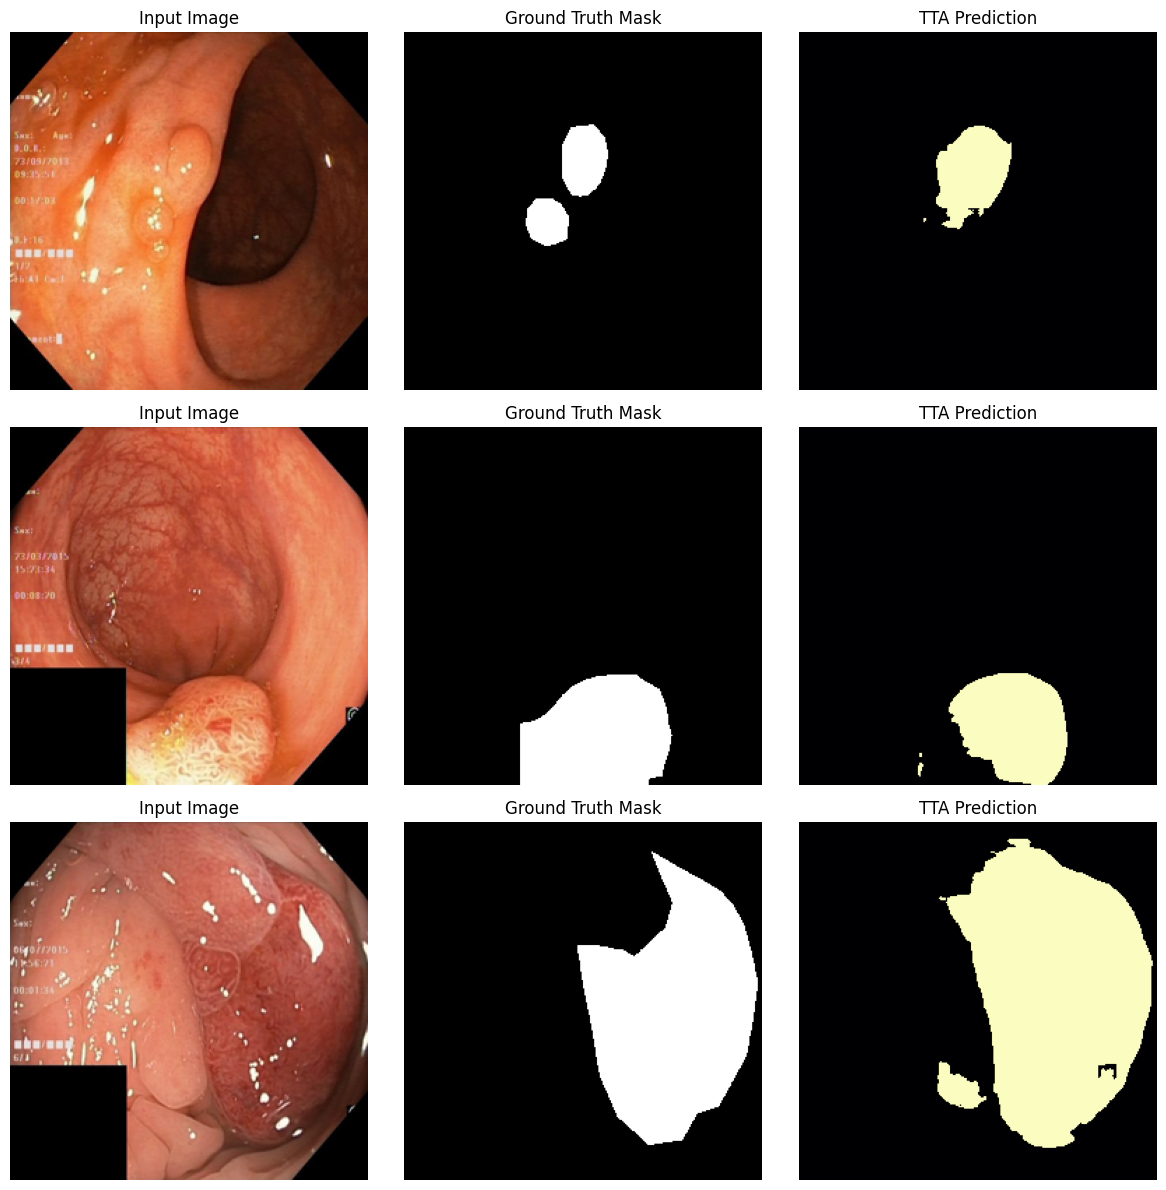

In [5]:
# Force load the BEST weights from the current run
if os.path.exists('best_transunet.pth'):
    print("Loading BEST trained weights...")
    model.load_state_dict(torch.load('best_transunet.pth', map_location=device))
else:
    print("WARNING: Best weights not found!")

def predict_with_tta(model, image_tensor):
    model.eval()
    with torch.no_grad():
        with autocast('cuda'):
            # 1. Original
            p1 = model(image_tensor)
            # 2. H-Flip
            p2 = torch.flip(model(torch.flip(image_tensor, dims=[-1])), dims=[-1])
            # 3. V-Flip
            p3 = torch.flip(model(torch.flip(image_tensor, dims=[-2])), dims=[-2])
            # 4. Rot180
            p4 = torch.rot90(model(torch.rot90(image_tensor, k=2, dims=[-2, -1])), k=-2, dims=[-2, -1])

            # Apply sigmoid to logits and average
            final_probs = (torch.sigmoid(p1) + torch.sigmoid(p2) + torch.sigmoid(p3) + torch.sigmoid(p4)) / 4.0
            return final_probs

test_dice, test_iou, test_acc = 0, 0, 0
results = []

for idx, (img, mask) in enumerate(tqdm(test_loader, desc="Running TTA on Test Set")):
    img, mask = img.to(device), mask.to(device)

    final_probs = predict_with_tta(model, img)

    d, iou, acc = calculate_metrics(final_probs[0], mask[0])
    test_dice += d
    test_iou += iou
    test_acc += acc

    if idx < 3:
        results.append((img.cpu(), mask.cpu(), final_probs.cpu()))

num_test = len(test_loader)
print("\n=== FINAL TEST RESULTS (TTA) ===")
print(f"Pixel Accuracy: {test_acc/num_test:.4f}")
print(f"Mean Dice:      {test_dice/num_test:.4f}")
print(f"Mean IoU:       {test_iou/num_test:.4f}")
print("================================")

# Visualization Plot
fig, axes = plt.subplots(3, 3, figsize=(12, 12))
for i in range(3):
    img_t, mask_t, pred_prob = results[i]

    img_unnorm = TF.normalize(
        img_t[0],
        mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
        std=[1/0.229, 1/0.224, 1/0.225]
    )

    img_show = np.clip(img_unnorm.permute(1, 2, 0).numpy(), 0, 1)

    axes[i, 0].imshow(img_show)
    axes[i, 0].set_title("Input Image")
    axes[i, 0].axis('off')

    axes[i, 1].imshow(mask_t[0][0].numpy(), cmap='gray')
    axes[i, 1].set_title("Ground Truth Mask")
    axes[i, 1].axis('off')

    axes[i, 2].imshow((pred_prob[0][0].numpy() > 0.5).astype(float), cmap='magma')
    axes[i, 2].set_title("TTA Prediction")
    axes[i, 2].axis('off')

plt.tight_layout()
plt.show()

## Deploying

In [6]:
!pip install -q onnx onnxscript

import torch
import torch.onnx

# 1. Load the best weights (TransUNet is already in memory from Cell 3)
model = TransUNet()
model.load_state_dict(torch.load('best_transunet.pth', map_location='cpu'))
model.eval()

# 2. Create a dummy input (1 batch, 3 channels, 256x256 image)
dummy_input = torch.randn(1, 3, 256, 256)

# 3. Export to ONNX
onnx_file_path = "transunet_optimized.onnx"
torch.onnx.export(
    model,
    dummy_input,
    onnx_file_path,
    export_params=True,
    opset_version=14,
    do_constant_folding=True,
    input_names=['input'],
    output_names=['output'],
    dynamic_axes={'input': {0: 'batch_size'}, 'output': {0: 'batch_size'}}
)

print(f"Export complete: {onnx_file_path}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 97.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 722.0/722.0 kB 59.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.8/185.8 kB 21.3 MB/s eta 0:00:00


/tmp/ipykernel_3721/4203844215.py:16: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0901 10:39:25.028000 3721 torch/onnx/_internal/exporter/_compat.py:133] Setting ONNX exporter to use operator set version 18 because the requested opset_version 14 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[torch.onnx] Obtain model graph for `TransUNet([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `TransUNet([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


/usr/lib/python3.13/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...


Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/onnxscript/version_converter/__init__.py", line 137, in call
    converted_proto = _c_api_utils.call_onnx_api(
        func=_partial_convert_version, model=model
    )
  File "/usr/local/lib/python3.13/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
  File "/usr/local/lib/python3.13/dist-packages/onnxscript/version_converter/__init__.py", line 132, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~^
        proto, target_version=self.target_version
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    )
    ^
  File "/usr/local/lib/python3.13/dist-packages/onnx/version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_str, target_version)
RuntimeError: /project/onnx/version_converter/adapters/no_previous_version.h:24: adap

[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
Export complete: transunet_optimized.onnx
